## Making of activity/weights

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString
import numpy as np
import networkx as nx
from itertools import combinations

In [2]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )
    
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/tmp/ipykernel_405221/146572828.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [3]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

/tmp/ipykernel_405221/1801734949.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [4]:
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

In [5]:
gdf_stops_3857.head()

,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code,geometry
51,8603317,NaN,Vestamager St. (Metro),NaN,55.619391,12.575297,0,NaN,0,NaN,POINT (1399875.659 7483017.289)
52,8603315,NaN,Ørestad St. (Metro),NaN,55.629055,12.579389,0,NaN,0,NaN,POINT (1400331.178 7484922.633)
53,8603312,NaN,Sundby St. (Metro),NaN,55.645199,12.585728,0,NaN,0,NaN,POINT (1401036.832 7488106.615)
54,8603313,NaN,Bella Center St. (Metro),NaN,55.638051,12.582928,0,NaN,0,NaN,POINT (1400725.138 7486696.697)
55,8603310,NaN,Islands Brygge St. (Metro),NaN,55.663422,12.585217,0,NaN,0,NaN,POINT (1400979.948 7491702.202)


based on this source:
https://metroselskabet.dk/en/about-us/about-the-metro/passenger-numbers-on-the-metro/

We find that our the number of passengers between stations are in the range 1000 - 36000 daily pssengers

In [6]:
def neighbore_threshold_and_edge_dist(gdf_stops_3857):
    dict_nodes = {}

    gdf_utm = gdf_stops_3857.to_crs(gdf_stops_3857.estimate_utm_crs())
    gdf = gdf_utm[["stop_name", "geometry"]].dropna().reset_index(drop=True)
    # print(gdf)

    # x, y coordinates compatable to meters - two lists of coordinates
    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()

    threshold = 0

    for i, node in gdf.iterrows():
        dict_nodes[node["stop_name"]] = {}
        if len(xs) != len(ys):
            print("xs and ys is not same length")
            break
        
        temp_threshold = float('inf')
        for compare in range(len(xs)):
            if i == compare:
                continue
            dx = xs[i] - xs[compare]
            dy = ys[i] - ys[compare]
            d = np.hypot(dx, dy)
            other_stop = gdf.loc[compare, "stop_name"]
            dict_nodes[node["stop_name"]][other_stop] = d
            if d < temp_threshold:
                temp_threshold = d


        if temp_threshold > threshold:
            threshold = temp_threshold

    return threshold, dict_nodes


def within_treshold(threshold, dict_nodes, df):
    valid_connections = {}
    for node, neighbors in dict_nodes.items():
        for connection, distance_between_stations in neighbors.items():
            weight = df.loc[df["stop_name"] == connection, "weight"]
            if not weight.empty:
                weight = weight.values[0]
            if distance_between_stations <= threshold:
                if node in valid_connections:
                    valid_connections[node].append((connection, weight))
                else:
                    valid_connections[node] = [(connection, weight)]

    return valid_connections

In [24]:
## Initiat the all node pairs and generate a random number of people that travel between them

def generate_trip_weight(df, rangestart, rangestop):

    # Set a seed so we dont need to save the file locally
    random.seed(154)

    all_nodes = df["stop_name"].tolist()

    pairs = list(combinations(all_nodes, 2))

    pair_list = []

    for nodes in pairs:
        w = random.randrange(rangestart, rangestop)
        pair_list.append((nodes, w))
    
    return pair_list

In [ ]:
## Sum the nodes total weight by all trips to said node
def create_weights(df, pair_list):
    weighted_df = df.copy()
    weighted_df["weight"] = ""

    all_nodes = df["stop_name"].tolist()
    
    for unique_node in all_nodes:
        total_weight = 0
        for (node1, node2), w in pair_list:
            if node1 == unique_node or node2 == unique_node:
                total_weight += w

        weighted_df.loc[weighted_df["stop_name"] == unique_node, 'weight'] = total_weight


    return weighted_df

## Start the algorithmn

In [31]:
# Parameters
max_routes = 4
max_stops = 17
min_stops = 13
threshold = 1350
total_kids = 2
total_number_of_node = 44

pair_list = generate_trip_weight(gdf_stops_3857, 150, 250)
gdf_stops_3857_weights = create_weights(gdf_stops_3857, pair_list)
_, distance_dict = neighbore_threshold_and_edge_dist(gdf_stops_3857_weights) ## Dosent exist yet 'gdf_stops_3857_weights'
valid_connections = within_treshold(threshold, distance_dict, gdf_stops_3857_weights) ## Dosent exist yet 'gdf_stops_3857_weights'

accepted_kids = []

while len(accepted_kids) < total_kids:
    all_routes = {}
    potential_start = gdf_stops_3857_weights["stop_name"].tolist() ## Dosent exist yet 'gdf_stops_3857_weights'

    used_nodes = set()  # <-- nodes already used in ANY completed route

    routes = 1

    edge_list = {}

    while routes < max_routes + 1:
        if not potential_start:
            break

        route_current = []
        start_node = random.choice(potential_start)
        route_current.append(start_node)

        while len(route_current) < max_stops:
            curr_node = route_current[-1]

            if curr_node in potential_start:
                potential_start.remove(curr_node)

            # filter out nodes already in this route
            poss_neighbors = [n for n in valid_connections[curr_node] if n[0] not in route_current]

            # dead-end handling
            if not poss_neighbors:
                if len(route_current) < min_stops:
                    route_current.reverse()
                    curr_node = route_current[-1]

                    poss_neighbors = [n for n in valid_connections[curr_node] if n[0] not in route_current]
                    if not poss_neighbors:
                        break
                else:
                    break


            neighbor_node = []
            neighbor_weights = []
            for i in poss_neighbors:
                neighbor_node.append(i[0])
                neighbor_weights.append(i[1])

            next_node = random.choices(neighbor_node, weights=neighbor_weights, k=1)[0]

            route_current.append(next_node)

            if curr_node in edge_list:
                edge_list[curr_node].append(next_node)
            else:
                edge_list[curr_node] = [next_node]

        all_routes[routes] = route_current
        routes += 1

    ## Check if its one componet 
    G = nx.from_dict_of_lists(edge_list)
    is_one_component = nx.is_connected(G)

    if is_one_component and G.number_of_nodes() == total_number_of_node:
        evaluation_score = 0
        for (node1, node2), w in pair_list:
            unweighted_path = nx.shortest_path(G, source=node1, target=node2)
            temp_score = w * len(unweighted_path)
            evaluation_score += temp_score
                
        all_routes["Score"] = evaluation_score
        all_routes["Number of edges"] = G.number_of_edges()
        accepted_kids.append(all_routes)
    else:
        continue

#accepted_kids

In [32]:
accepted_kids

[{1: ['Nordhavn St. (Metro)',
   'Orientkaj St. (Metro)',
   'Poul Henningsens Plads St. (Metro)',
   'Trianglen St. (Metro)',
   'Vibenshus Runddel St. (Metro)',
   'Skjolds Plads St. (Metro)',
   'Nørrebros Runddel St. (Metro)',
   'Nørrebro St. (Metro)',
   'Nuuks Plads St. (Metro)',
   'Frederiksberg St. (Metro)',
   'Aksel Møllers Have St. (Metro)',
   'Fasanvej St. (Metro)',
   'Lindevang St. (Metro)',
   'Flintholm St. (Metro)',
   'Vanløse St. (Metro)'],
  2: ['Vestamager St. (Metro)',
   'Ørestad St. (Metro)',
   'Bella Center St. (Metro)',
   'Sundby St. (Metro)',
   'DR Byen St. (Metro)',
   'Islands Brygge St. (Metro)',
   'Amagerbro St. (Metro)',
   'Christianshavn St. (Metro)',
   'Gammel Strand St. (Metro)',
   'Kongens Nytorv St. (Metro)',
   'Nørreport St. (Metro)',
   'Forum St. (Metro)',
   'Frederiksberg Allé St. (Metro)',
   'Enghave Plads St. (Metro)',
   'Havneholmen St. (Metro)',
   'Enghave Brygge St. (Metro)',
   'Sluseholmen St. (Metro)'],
  3: ['København Sy

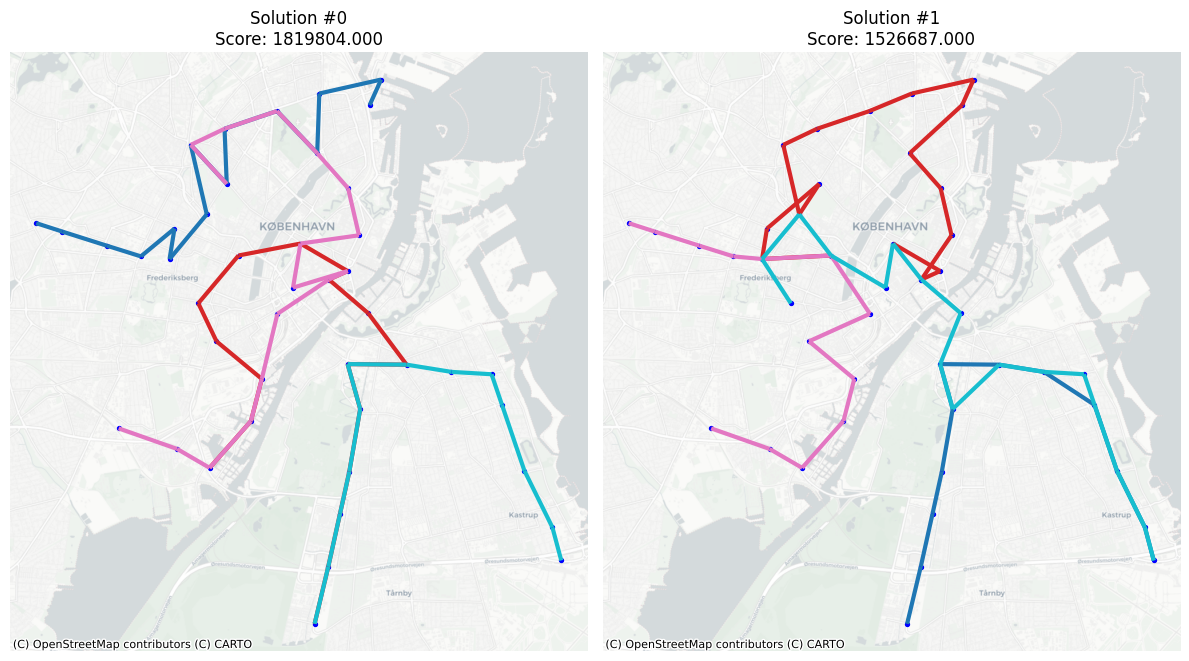

In [33]:
# -------- LINE CREATION --------
def create_line(p1_name, p2_name, gdf_stops_3857):
    p1 = gdf_stops_3857.loc[
        gdf_stops_3857["stop_name"] == p1_name, "geometry"
    ].iloc[0]

    p2 = gdf_stops_3857.loc[
        gdf_stops_3857["stop_name"] == p2_name, "geometry"
    ].iloc[0]

    return LineString([p1, p2])


# -------- BUILD EDGES --------
def build_edges_gdf(solution_routes_dict, gdf_stops_3857):
    records = []

    for route_id, route in solution_routes_dict.items():

        # Only process actual routes (skip score or other metadata)
        if not isinstance(route, (list, tuple)):
            continue

        for k in range(len(route) - 1):
            p1 = route[k]
            p2 = route[k + 1]

            line = create_line(p1, p2, gdf_stops_3857)

            records.append({
                "geometry": line,
                "route_id": route_id
            })

    return gpd.GeoDataFrame(records, crs=gdf_stops_3857.crs)


# -------- MAIN PLOT --------
n = len(accepted_kids)
max_cols = 4

# Compute grid size
ncols = min(max_cols, n) if n > 0 else 1
nrows = (n + ncols - 1) // ncols  # ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(6 * ncols, 8 * nrows),
    sharex=True,
    sharey=True
)

# Make axes always a flat 1D list (works for any nrows/ncols)
axes = np.atleast_1d(axes).ravel()

# Plot each solution
for idx, solution_dict in enumerate(accepted_kids):
    ax = axes[idx]

    # Extract score safely
    score = solution_dict.get("Score", None)

    edges_gdf = build_edges_gdf(solution_dict, gdf_stops_3857)

    edges_gdf.plot(
        ax=ax,
        column="route_id",
        categorical=True,
        legend=False,
        linewidth=3
    )

    gdf_stops_3857.plot(
        ax=ax,
        color="blue",
        markersize=8
    )

    cx.add_basemap(
        ax,
        source=cx.providers.CartoDB.Positron,
        crs=gdf_stops_3857.crs
    )

    # Title + subheader
    if isinstance(score, (int, float)):
        ax.set_title(f"Solution #{idx}\nScore: {score:.3f}")
    elif score is not None:
        ax.set_title(f"Solution #{idx}\nScore: {score}")
    else:
        ax.set_title(f"Solution #{idx}")

    ax.set_axis_off()
    ax.set_aspect("equal")

# Hide any unused subplots (when n is not a multiple of ncols)
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
